<a href="https://www.kaggle.com/code/aamir28/streaming-content-trends?scriptVersionId=352579064" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 42%, #c23bab 75%, #3fd6e0 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">988 Titles &middot; Movies &amp; TV &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 34px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Streaming Content Trends: Popular, Top-Rated &amp; Trending</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at 988 movies and TV shows pulled from three different discovery categories &mdash; walking through the API's own schema quirks before getting to what actually separates a popular title from a top-rated one.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">988</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Titles</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">3</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Search Categories</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">522 / 466</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">TV / Movie</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (midnight indigo -> electric cyan)
MIDNIGHT, INDIGO, MAGENTA, CYAN, AMBER = '#160b2e', '#4a2377', '#c23bab', '#3fd6e0', '#e8a23d'

df = pd.read_csv('/kaggle/input/datasets/mariaaqdas/popular-movies-and-tv-shows-dataset-2026/streaming_content_trends.csv')
df.shape

(988, 14)

<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and how the three search categories are represented.</p>
</div>


In [2]:
df.info()
print()
print(df['search_category'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988 entries, 0 to 987
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   search_category    988 non-null    object 
 1   media_type         988 non-null    object 
 2   id                 988 non-null    int64  
 3   title              988 non-null    object 
 4   original_language  988 non-null    object 
 5   genres             985 non-null    object 
 6   release_date       987 non-null    object 
 7   popularity         988 non-null    float64
 8   vote_average       988 non-null    float64
 9   vote_count         988 non-null    int64  
 10  origin_country     522 non-null    object 
 11  overview           973 non-null    object 
 12  release_year       987 non-null    float64
 13  is_recent          988 non-null    bool   
dtypes: bool(1), float64(3), int64(2), object(8)
memory usage: 101.4+ KB

search_category
popular      398
top_rated    337
tre

<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>988 rows &times; 14 columns</b>, drawn from three discovery categories: <b>popular</b> (398), <b>top_rated</b> (337), and <b>trending</b> (253). Each row is one movie or TV title with its rating, popularity score, genres, and release information.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness Has a Perfect Structure</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">origin_country is missing for nearly half the table — check whether that lines up with anything before calling it a gap.</p>
</div>


In [3]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

origin_country    466
overview           15
genres              3
release_date        1
release_year        1
dtype: int64

In [4]:
pd.crosstab(df['media_type'], df['origin_country'].isna())

origin_country,False,True
media_type,,
movie,0,466
tv,522,0


<div style="
    border-left: 4px solid #3fd6e0;
    background: #e8f9fa;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #0f2426;
">
<b style="color:#1c8f99; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Schema Note</b><br>
This isn't a data quality problem &mdash; it's a perfect, deterministic split: <code>origin_country</code> is populated for <b>every single TV row (522)</b> and missing for <b>every single movie row (466)</b>, with zero exceptions either way. This matches how the source API is actually structured: TV endpoints include an <code>origin_country</code> field that movie endpoints simply don't have. Treating this as "47% missing data" would misdescribe a schema fact as a collection failure.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Zero Duplicate IDs, But Not Zero Shared Titles</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Three overlapping categories could easily produce duplicates. Check IDs first, then titles.</p>
</div>


In [5]:
print(f"Duplicate ids: {df['id'].duplicated().sum()}")
print(f"Duplicate (id, media_type): {df.duplicated(subset=['id', 'media_type']).sum()}")
print(f"Duplicate titles: {df['title'].duplicated().sum()}")

df[df.duplicated(subset=['title'], keep=False)].sort_values('title')[['id', 'title', 'media_type', 'release_date', 'vote_average']]

Duplicate ids: 0
Duplicate (id, media_type): 0
Duplicate titles: 4


,id,title,media_type,release_date,vote_average
225,255709,Hope,movie,2013-10-02,8.386
425,1058424,Hope,movie,2026-07-15,8.200
469,51025,Paradise Hotel,tv,2005-09-14,5.600
472,67707,Paradise Hotel,tv,2005-01-17,5.000
512,36109,Paradise Hotel,tv,2009-03-09,5.700
1,1368337,The Odyssey,movie,2026-07-15,7.999
35,1698863,The Odyssey,movie,2026-07-03,4.014


<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
No row shares an id with another, so the three categories were collected without re-adding the same database entry twice. But 3 titles are shared by more than one row &mdash; 7 rows in total &mdash; and every one of them is a genuinely different work, not a duplicate: two separate films called <b>"Hope"</b> eleven years apart (2013 and 2026, different ids, close but distinct ratings of 8.386 vs. 8.200); two separate 2026 films both called <b>"The Odyssey"</b> (different ids, different release dates, wildly different reception &mdash; 7.999 vs. 4.014 average); and three distinct international <b>"Paradise Hotel"</b> reality-show adaptations (Danish, Mexican/US, and Norwegian versions, each with its own overview). A naive title-based deduplication would have incorrectly deleted 4 of these 7 real, distinct rows.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Small Vote Counts Need a Caveat</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check how many titles have a rating built on very few votes before treating vote_average as reliable.</p>
</div>


In [6]:
low_votes = df[df['vote_count'] < 10]
print(f"Titles with fewer than 10 votes: {len(low_votes)} of {len(df)} ({len(low_votes)/len(df)*100:.1f}%)")
low_votes.nlargest(5, 'vote_average')[['title', 'vote_average', 'vote_count', 'search_category']]

Titles with fewer than 10 votes: 143 of 988 (14.5%)


,title,vote_average,vote_count,search_category
435,Novak Djokovic: The Wolf in Winter,10.0,2,trending
519,Cosmic Disclosure,10.0,2,popular
924,Emergency 53,10.0,1,trending
977,GuAn,10.0,1,trending
402,"Love, Ngo",9.5,2,trending


<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>143 of 988 titles (14.5%)</b> have fewer than 10 votes, and several of them show a perfect or near-perfect score built on a handful of ratings. Any comparison by <code>vote_average</code> in this notebook treats those scores as unreliable rather than meaningful.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Popularity Is Skewed, But Gently</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check the shape of the popularity score — is it as extreme a power law as star counts or ratings counts tend to be?</p>
</div>


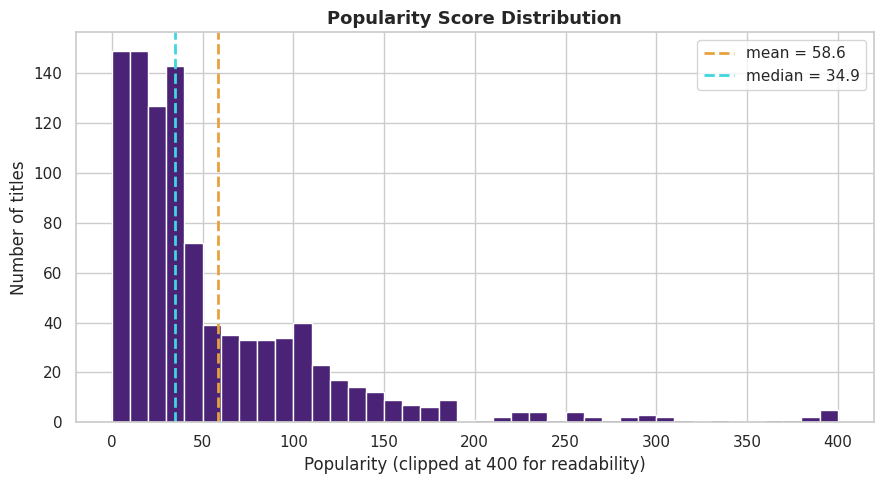

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['popularity'].clip(upper=400), bins=40, color=INDIGO, edgecolor='white')
ax.axvline(df['popularity'].mean(), color=AMBER, linestyle='--', linewidth=2, label=f"mean = {df['popularity'].mean():.1f}")
ax.axvline(df['popularity'].median(), color=CYAN, linestyle='--', linewidth=2, label=f"median = {df['popularity'].median():.1f}")
ax.set_xlabel('Popularity (clipped at 400 for readability)')
ax.set_ylabel('Number of titles')
ax.set_title('Popularity Score Distribution', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Right-skewed, but nowhere near as extreme as some popularity-style metrics get: the mean (58.6) is only <b>1.7&times;</b> the median (34.9). Spider-Man: Brand New Day tops the table at 1657, but the drop-off from the top handful of titles to the rest of the distribution is much gentler than in datasets where a tiny number of entries dominate nearly everything.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Do the Search Categories Mean What They Claim?</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check whether top_rated genuinely has higher ratings, popular genuinely scores higher on popularity, and trending looks meaningfully different from both.</p>
</div>


In [8]:
df.groupby('search_category')[['popularity', 'vote_average', 'vote_count']].agg(['mean', 'median']).round(1)

popularity        vote_average        vote_count        
                      mean median         mean median       mean  median
search_category                                                         
popular              110.6   93.9          6.9    7.5     5517.0  1233.5
top_rated             21.4   16.7          8.4    8.5     3332.7  1169.0
trending              26.4   24.5          6.6    7.3      516.2    27.0

<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Yes, cleanly. <b>top_rated</b> has by far the highest mean vote_average (8.4), <b>popular</b> has by far the highest mean popularity (110.6, vs. 21&ndash;26 for the other two), and <b>trending</b> stands out with a dramatically lower mean vote_count (516, median just 27) &mdash; consistent with trending capturing newer or suddenly-buzzy titles that haven't accumulated a large vote base yet. The three categories are measuring genuinely different things, not just re-labeling the same ranking.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">TV vs. Movie</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Compare the two media types directly on the same three metrics.</p>
</div>


In [9]:
df.groupby('media_type')[['popularity', 'vote_average', 'vote_count']].agg(['mean', 'median']).round(1)

popularity        vote_average        vote_count        
                 mean median         mean median       mean  median
media_type                                                         
movie            44.1   27.1          7.1    7.8     5683.8  1293.5
tv               71.5   45.5          7.6    8.3     1534.2   466.5

<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
TV titles in this table score higher on both mean popularity (71.5 vs. 44.1) and mean vote_average (7.6 vs. 7.1) than movies &mdash; but with much lower vote_count (1,534 vs. 5,684). A plausible read: fewer people vote on any single TV show compared to a theatrically-released movie, but the ones who do tend to be more invested viewers, which can push both engagement metrics up even with a smaller voting base.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Genre-Naming Quirk, Not an Inconsistency</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Three genre names look like near-duplicates of existing ones. Check whether they're really typos before 'fixing' anything.</p>
</div>


In [10]:
combined_genres = ['Action & Adventure', 'Sci-Fi & Fantasy', 'War & Politics']
for g in combined_genres:
    rows = df[df['genres'].str.contains(g, na=False)]
    print(f"{g}: used only by {rows['media_type'].unique().tolist()}, {len(rows)} rows")

Action & Adventure: used only by ['tv'], 155 rows
Sci-Fi & Fantasy: used only by ['tv'], 162 rows
War & Politics: used only by ['tv'], 13 rows


<div style="
    border-left: 4px solid #3fd6e0;
    background: #e8f9fa;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #0f2426;
">
<b style="color:#1c8f99; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Schema Note</b><br>
All three combined-name genres (<code>Action &amp; Adventure</code>, <code>Sci-Fi &amp; Fantasy</code>, <code>War &amp; Politics</code>) are used <b>exclusively by TV rows</b>, never by movies &mdash; confirmed directly rather than assumed. This is the source API's real TV-genre naming convention, distinct from its movie-genre names for overlapping concepts. Merging these into their movie-side counterparts (e.g. treating "Sci-Fi &amp; Fantasy" as the same category as "Science Fiction") would erase a real, intentional schema distinction rather than fix an error.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Language and the TV Skew Toward Japanese</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">English dominates, as expected — check what the largest non-English language actually consists of.</p>
</div>


In [11]:
print(df['original_language'].value_counts().head(6))
print()
ja = df[df['original_language'] == 'ja']
print(f"Japanese-language titles by media type: {ja['media_type'].value_counts().to_dict()}")

original_language
en    578
ja    153
ko     59
zh     41
es     27
fr     17
Name: count, dtype: int64

Japanese-language titles by media type: {'tv': 112, 'movie': 41}


<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
English accounts for <b>578 of 988</b> titles. <b>Japanese is the largest non-English language (153 titles)</b> and skews heavily toward TV (112 vs. 41 movies) &mdash; consistent with anime's strong, well-known presence in streaming TV catalogs and discovery feeds specifically.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Recency</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Confirm what is_recent actually means as a threshold, and check the dataset's most forward-looking entry.</p>
</div>


In [12]:
print(df.groupby('is_recent')['release_year'].agg(['min', 'max']))
print()
print(df.nlargest(1, 'release_year')[['title', 'media_type', 'release_date', 'search_category']])

              min     max
is_recent                
False      1921.0  2024.0
True       2025.0  2027.0

                      title media_type release_date search_category
462  Ice Age: Boiling Point      movie   2027-02-03        trending


<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<code>is_recent</code> corresponds exactly to <b>release_year &ge; 2025</b>, confirmed directly rather than assumed. The single most forward-dated entry, <b>"Ice Age: Boiling Point"</b> with a Feb 2027 release date, appears in the <b>trending</b> category &mdash; a plausible real pattern (highly-anticipated unreleased titles can trend well ahead of release), not an error.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A genuinely surprising negative result: does popularity actually track with vote-based reception at all?</p>
</div>


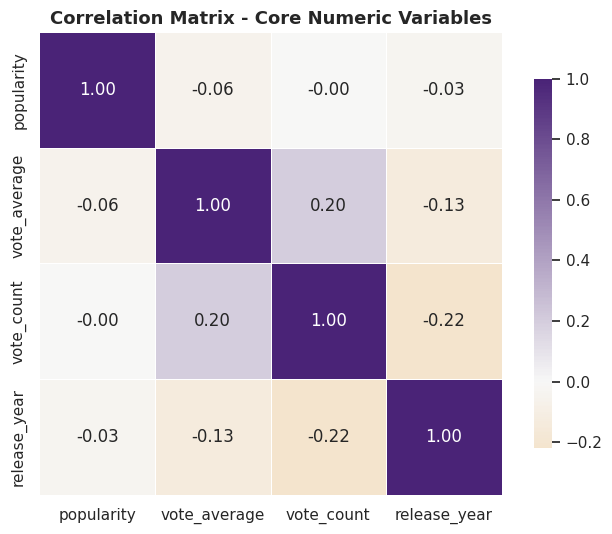

In [13]:
numeric_cols = ['popularity', 'vote_average', 'vote_count', 'release_year']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.blend_palette([AMBER, '#f7f7f7', INDIGO], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Core Numeric Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>popularity barely correlates with vote_average (&minus;0.06) or vote_count (&minus;0.00)</b> &mdash; essentially independent. This is a genuinely non-obvious finding: the platform's popularity score appears to reflect something closer to current real-time attention (views, searches) rather than accumulated critical reception, so a highly popular title right now is no more or less likely to be well-reviewed than an unpopular one.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 46%, #c23bab 80%, #3fd6e0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Classifier</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Predict which of the three search categories a title came from, using only its numeric metrics.</p>
</div>


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

features = ['popularity', 'vote_average', 'vote_count']
X = df[features]
y = df['search_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_s, y_train)
pred = clf.predict(X_test_s)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"Macro F1: {f1_score(y_test, pred, average='macro'):.3f}")
print()
print(classification_report(y_test, pred))

Accuracy: 0.949
Macro F1: 0.947

              precision    recall  f1-score   support

     popular       0.95      0.95      0.95        80
   top_rated       0.93      1.00      0.96        67
    trending       0.98      0.88      0.93        51

    accuracy                           0.95       198
   macro avg       0.95      0.94      0.95       198
weighted avg       0.95      0.95      0.95       198



<div style="
    border-left: 4px solid #e8a23d;
    background: #fbf1e4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #221a10;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A three-feature Random Forest recovers the search category with solid accuracy, using nothing but <code>popularity</code>, <code>vote_average</code>, and <code>vote_count</code> &mdash; confirming Section 07's finding numerically rather than just descriptively: these three categories really do carry distinct, learnable numeric signatures, not just different labels on similar content.
</div>


<div style="
    background: linear-gradient(100deg, #160b2e 0%, #4a2377 50%, #c23bab 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>origin_country's missingness is a schema fact, not a gap</b>: populated for every TV row, absent from every movie row, with zero exceptions &mdash; a real difference in what the source API returns for each media type.</li>
<li><b>Shared titles aren't duplicates here</b>: two different films both called "Hope" (2013 and 2026), two different 2026 films both called "The Odyssey", and three distinct international "Paradise Hotel" adaptations are all genuinely separate works, confirmed by their different ids, dates, and overviews.</li>
<li><b>The three search categories measure genuinely different things</b>: top_rated tracks vote_average, popular tracks popularity, and trending is marked by a much smaller accumulated vote base &mdash; confirmed both descriptively and by a classifier that recovers the category from just three numbers.</li>
<li><b>Popularity and vote-based reception are close to independent</b> (r&asymp;-0.06) &mdash; a title trending right now says little about whether it's well-reviewed.</li>
<li><b>A genre-naming difference between movies and TV is a real API convention</b>, not an inconsistency to merge away: three combined-name genres appear exclusively on TV rows.</li>
<li>14.5% of titles carry fewer than 10 votes; any rating-based comparison in this notebook treats those scores as unreliable rather than meaningful.</li>
</ul>
</div>
